# Carregando e tratando um dataset da web

Neste notebook vamos:

1. Carregar um dataset pequeno diretamente de uma URL pública.
2. Explorar sua estrutura (tipos, valores ausentes, duplicatas).
3. Tratar os problemas encontrados (valores ausentes, tipos, duplicatas).
4. Salvar o dataset tratado em um novo arquivo CSV.

Vamos usar o dataset **Titanic**, disponibilizado publicamente no repositório de dados de exemplo do `seaborn` no GitHub. Ele é pequeno (~891 linhas) e tem vários problemas típicos de dados reais (valores ausentes, colunas redundantes, tipos misturados), o que o torna ótimo para praticar tratamento de dados.

In [5]:
import pandas as pd
import numpy as np
import category_encoders as ce

pd.set_option('display.max_columns', None)

## 1. Carregando o dataset da web

Usamos `pd.read_csv()` apontando diretamente para a URL raw do arquivo CSV no GitHub — não é necessário baixar o arquivo manualmente.

In [6]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
dados = pd.read_csv(url)

print('Formato do dataset:', dados.shape)
dados.head()

Formato do dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Explorando a estrutura dos dados

In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [8]:
dados.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Valores ausentes

Vamos verificar quantos valores ausentes existem em cada coluna, em número absoluto e em percentual.

In [9]:
ausentes = dados.isnull().sum()
percentual = (ausentes / len(dados) * 100).round(2)

resumo_ausentes = pd.DataFrame({'qtd_ausentes': ausentes, 'percentual': percentual})
resumo_ausentes[resumo_ausentes['qtd_ausentes'] > 0].sort_values('percentual', ascending=False)

,qtd_ausentes,percentual
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


### Linhas duplicadas

In [10]:
print('Linhas duplicadas:', dados.duplicated().sum())

Linhas duplicadas: 107


### Balanceamento da variável alvo (`survived`)

Antes de tratar os dados, é importante verificar se as classes da variável que queremos prever estão balanceadas. Um forte desbalanceamento pode exigir técnicas específicas mais adiante (ex.: `class_weight`, oversampling/undersampling, métricas diferentes de acurácia).

                    contagem  percentual (%)
Não sobreviveu (0)       549            61.6
Sobreviveu (1)           342            38.4


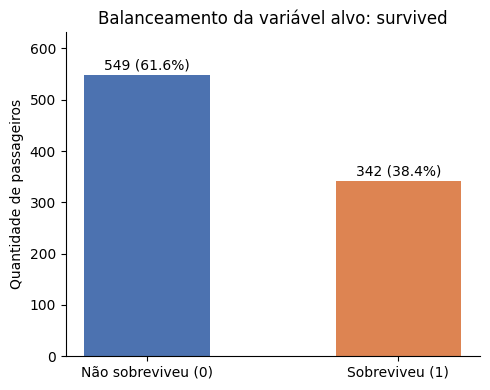

In [11]:
import matplotlib.pyplot as plt

contagem = dados['survived'].value_counts().sort_index()
percentual = (contagem / len(dados) * 100).round(1)

resumo_balanceamento = pd.DataFrame({'contagem': contagem, 'percentual (%)': percentual})
resumo_balanceamento.index = ['Não sobreviveu (0)', 'Sobreviveu (1)']
print(resumo_balanceamento)

fig, ax = plt.subplots(figsize=(5, 4))
cores = ['#4C72B0', '#DD8452']  # azul e laranja, com bom contraste e distinguíveis para daltonismo
barras = ax.bar(resumo_balanceamento.index, contagem.values, color=cores, width=0.5)

for barra, valor, pct in zip(barras, contagem.values, percentual.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 5, f'{valor} ({pct}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Quantidade de passageiros')
ax.set_title('Balanceamento da variável alvo: survived')
ax.set_ylim(0, contagem.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

O dataset Titanic apresenta um desbalanceamento moderado: aproximadamente 62% dos passageiros não sobreviveram contra 38% que sobreviveram. Não é um desbalanceamento extremo (como 95%/5%), mas já é relevante o suficiente para, em uma etapa futura de modelagem, considerar `class_weight='balanced'`, estratificação no `train_test_split` e métricas como F1-score ou AUC em vez de apenas acurácia.

## 3. Tratando os dados

Com base na exploração acima, vamos aplicar os seguintes tratamentos:

- **`deck`** tem mais de 70% de valores ausentes → coluna será removida.
- **`embark_town`** e **`embarked`** são redundantes (mesma informação); manteremos apenas `embarked` e removeremos as poucas linhas com valor ausente nela.
- **`age`** tem valores ausentes → preencher com a **mediana** (mais robusta a outliers que a média).
- Colunas booleanas (`adult_male`, `alone`) já vêm como `bool` — não precisam de tratamento.
- Remover linhas duplicadas, se houver.

In [12]:
dados_tratados = dados.copy()
dados_tratados

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [13]:
#dados_tratados = dados.copy()


In [14]:

# Remove colunas com excesso de valores ausentes ou redundantes
dados_tratados = dados_tratados.drop(columns=['deck', 'embark_town'])


In [15]:

# Remove as poucas linhas sem porto de embarque
dados_tratados = dados_tratados.dropna(subset=['embarked'])

# Preenche idade ausente com a mediana
dados_tratados['age'] = dados_tratados['age'].fillna(dados_tratados['age'].median())

# Remove duplicatas, se existirem
dados_tratados = dados_tratados.drop_duplicates()

dados_tratados = dados_tratados.reset_index(drop=True)

print('Formato após tratamento:', dados_tratados.shape)
dados_tratados.head()

Formato após tratamento: (773, 13)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


### Verificando o resultado

Confirmando que não restaram valores ausentes nas colunas tratadas.

In [16]:
dados_tratados.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

## 4. Ajustando tipos de dados

Em vez de apenas converter as colunas categóricas (`sex`, `class`, `who`, `embarked`) para o tipo `category` do pandas, vamos usar a biblioteca `category_encoders` para transformá-las em valores numéricos com `PolynomialEncoder`.

O `PolynomialEncoder` assume que as categorias têm uma ordem implícita e cria **contrastes polinomiais** (colunas `.0`, `.1`, `.2`, ...) que capturam tendências lineares, quadráticas etc. entre os níveis — diferente do `OrdinalEncoder`, que gera apenas uma única coluna com números inteiros sequenciais. As colunas originais são substituídas pelas novas colunas de contraste.

In [17]:
colunas_categoricas = ['sex', 'class', 'who', 'embarked']

encoder_tipos = ce.PolynomialEncoder(cols=colunas_categoricas)
dados_tratados = encoder_tipos.fit_transform(dados_tratados)

dados_tratados.dtypes

survived        int64
pclass          int64
sex_0         float64
age           float64
sibsp           int64
parch           int64
fare          float64
embarked_0    float64
embarked_1    float64
class_0       float64
class_1       float64
who_0         float64
who_1         float64
adult_male       bool
alive          object
alone            bool
dtype: object

### Conferindo os contrastes gerados

O `PolynomialEncoder` guarda, para cada coluna original, a matriz de contrastes usada para gerar as novas colunas numéricas. Isso é essencial para interpretar o significado de cada coluna `.0`, `.1`, etc. depois.

In [18]:
for item in encoder_tipos.mapping:
    print(f"Coluna: {item['col']}")
    print(item['mapping'])
    print()

dados_tratados.head()

Coluna: sex
       sex_0
 1 -0.707107
 2  0.707107
-1  0.000000
-2  0.000000

Coluna: class
         class_0   class_1
 1 -7.071068e-01  0.408248
 2 -5.551115e-17 -0.816497
 3  7.071068e-01  0.408248
-1  0.000000e+00  0.000000
-2  0.000000e+00  0.000000

Coluna: who
           who_0     who_1
 1 -7.071068e-01  0.408248
 2 -5.551115e-17 -0.816497
 3  7.071068e-01  0.408248
-1  0.000000e+00  0.000000
-2  0.000000e+00  0.000000

Coluna: embarked
      embarked_0  embarked_1
 1 -7.071068e-01    0.408248
 2 -5.551115e-17   -0.816497
 3  7.071068e-01    0.408248
-1  0.000000e+00    0.000000
-2  0.000000e+00    0.000000



,survived,pclass,sex_0,age,sibsp,parch,fare,embarked_0,embarked_1,class_0,class_1,who_0,who_1,adult_male,alive,alone
0,0,3,-0.707107,22.0,1,0,7.2500,-7.071068e-01,0.408248,-7.071068e-01,0.408248,-7.071068e-01,0.408248,True,no,False
1,1,1,0.707107,38.0,1,0,71.2833,-5.551115e-17,-0.816497,-5.551115e-17,-0.816497,-5.551115e-17,-0.816497,False,yes,False
2,1,3,0.707107,26.0,0,0,7.9250,-7.071068e-01,0.408248,-7.071068e-01,0.408248,-5.551115e-17,-0.816497,False,yes,True
3,1,1,0.707107,35.0,1,0,53.1000,-7.071068e-01,0.408248,-5.551115e-17,-0.816497,-5.551115e-17,-0.816497,False,yes,False
4,0,3,-0.707107,35.0,0,0,8.0500,-7.071068e-01,0.408248,-7.071068e-01,0.408248,-7.071068e-01,0.408248,True,no,True


## 5. Salvando o dataset tratado

In [19]:
dados_tratados.to_csv('titanic_tratado.csv', index=False)
print('Dataset tratado salvo em titanic_tratado.csv')

Dataset tratado salvo em titanic_tratado.csv


## Resumo

| Etapa | Ação |
|---|---|
| Colunas com muitos ausentes (`deck`) | Removida |
| Coluna redundante (`embark_town`) | Removida |
| Poucas linhas sem `embarked` | Removidas |
| `age` ausente | Preenchida com a mediana |
| Duplicatas | Removidas |
| Colunas categóricas | Codificadas com `ce.PolynomialEncoder` (contrastes polinomiais, category_encoders) |

A partir daqui, `dados_tratados` está pronto para ser usado em etapas seguintes, como modelagem. Para explorar outras formas de codificação categórica (OneHot, TargetEncoder, CatBoostEncoder, etc.), veja o notebook [encoders.ipynb](encoders.ipynb).